# Data collection

The first steps of this project will be to master how to collect and retrieve the data through the nba_api and more precisely the playByPlay data. This will enable me to understand how the api works and to train a little bit before building the dataset with the desired features. 

In [ ]:
from nba_api.stats.endpoints import playbyplayv3
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import random
import requests
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

## Loading some game data 

In [5]:
# Finding the games_id for one season
season = '2022-23'
gamefinder = leaguegamefinder.LeagueGameFinder(
    season_nullable=season,
    league_id_nullable='00'
)

games = gamefinder.get_data_frames()[0]
print(games.head())
print(games.columns.tolist())

  SEASON_ID     TEAM_ID TEAM_ABBREVIATION       TEAM_NAME     GAME_ID  \
0     42022  1610612743               DEN  Denver Nuggets  0042200405   
1     42022  1610612748               MIA      Miami Heat  0042200405   
2     42022  1610612743               DEN  Denver Nuggets  0042200404   
3     42022  1610612748               MIA      Miami Heat  0042200404   
4     42022  1610612748               MIA      Miami Heat  0042200403   

    GAME_DATE      MATCHUP WL  MIN  PTS  ...  FT_PCT  OREB  DREB  REB  AST  \
0  2023-06-12  DEN vs. MIA  W  240   94  ...   0.565    11    46   57   21   
1  2023-06-12    MIA @ DEN  L  240   89  ...   0.875    11    33   44   18   
2  2023-06-09    DEN @ MIA  W  242  108  ...   0.762     5    29   34   26   
3  2023-06-09  MIA vs. DEN  L  240   95  ...   0.850     8    29   37   23   
4  2023-06-07  MIA vs. DEN  L  240   94  ...   0.789    10    23   33   20   

   STL  BLK  TOV  PF  PLUS_MINUS  
0    6    7   14  13         5.0  
1    9    7    8  21  

In [ ]:
games

In [6]:
print(f"===== Season {season} =====")
print(f"Number of games : {games.shape[0]}")
print(f"Number of features available : {games.shape[1]}")

===== Season 2022-23 =====
Number of games : 2790
Number of features available : 28


In [10]:
# Retrieving the plaByPlay data for one precise game
game_id = games['GAME_ID'].iloc[0]

time.sleep(1) # Important : nba_api has a rate limit, we always need to wait between different api calls

pbp = playbyplayv3.PlayByPlayV3(game_id=game_id)
df = pbp.get_data_frames()[0]

print(df.shape)
print(df.head(20))
print(df.columns.tolist())

(492, 24)
        gameId  actionNumber        clock  period      teamId teamTricode  \
0   0042200405             2  PT12M00.00S       1           0               
1   0042200405             4  PT12M00.00S       1  1610612743         DEN   
2   0042200405             7  PT11M43.00S       1  1610612743         DEN   
3   0042200405             7  PT11M43.00S       1  1610612748         MIA   
4   0042200405             9  PT11M39.00S       1  1610612748         MIA   
5   0042200405            10  PT11M28.00S       1  1610612743         DEN   
6   0042200405            11  PT11M08.00S       1  1610612748         MIA   
7   0042200405            12  PT11M06.00S       1  1610612743         DEN   
8   0042200405            13  PT10M58.00S       1  1610612743         DEN   
9   0042200405            15  PT10M57.00S       1  1610612748         MIA   
10  0042200405            16  PT10M38.00S       1  1610612748         MIA   
11  0042200405            16  PT10M38.00S       1  1610612743     

In [14]:
print(f"===== Game_ID {game_id} =====")
print(f"Opposing teams : {games[games["GAME_ID"]==game_id]["MATCHUP"].iloc[0]}")
print(f"Total number of actions : {df.shape[0]}")
print(f"Numbber of features : {df.shape[1]}")

===== Game_ID 0042200405 =====
Opposing teams : DEN vs. MIA
Total number of actions : 492
Numbber of features : 24


## Cleaning raw data

The next step after having retrieved the raw data is to clean it a little bit since we have some useless columns.
The idea is to build a dataframe for one game for the moment with the following columns :
- quarter (1,2,3,4, see later what to do for the overtime)
- time_remaining in the quarter (seconds)
- score_diff in the home team perspective
- home_team_possession (True/False) : categorical column indicating if the home team is in possession of the ball
- home_win (True or False):  **target value**

And then later more complex features that can give some interesting insights:
- momentum_5_min : a score differential over the last 5min in the perspective of the home team
- current_form_home_team : an int representing the number of wins of the home team over the last 10 games
- current_form_away_team : an int representing the number of wins of the away team over the last 10 games
- Team fouls in the current quarter (special treatment for the overtimes since the fouls does not reset)
- Timeouts left 

In the future we could think of even more advanced features related to the player on the floor and how good they are or other features that we could find relevant.

In [2]:
# Data cleaning

def clean_df(df):
    features_of_interest = ['quarter', 'time_remaining', 'score_diff', 'home_win'] # Yet to add : momentum, current_form_home/away, ...
    df_clean = df.copy()

    df_clean['quarter'] = df_clean['period']
    df_clean['time_remaining'] = 60*df_clean['clock'].str[2:4].astype(float) + df_clean['clock'].str[5:10].astype(float) # time remaining in the current quarter in seconds

    # Building a momentum feature
    # We need to look at the last 300s => 5min and compute the diff score on this period
    # beginning
    # df_clean['momentum'] = 

    df_clean['scoreHome'] = (df_clean['scoreHome'].replace('', np.nan).ffill())
    df_clean['scoreAway'] = (df_clean['scoreAway'].replace('', np.nan).ffill())

    df_clean['score_diff'] = df_clean['scoreHome'].astype(int) - df_clean['scoreAway'].astype(int)

    # Create the target value
    if df_clean['score_diff'].iloc[-1] > 0:
        df_clean['home_win'] = True
    else:
        df_clean['home_win'] = False

    df_clean = df_clean[features_of_interest]

    return df_clean


In [62]:
df_clean = clean_df(df=df)

In [ ]:
# We need to remove the rows that are exaclty the same
df_clean.drop_duplicates(inplace=True)

In [ ]:
df_clean

In [3]:
def compute_momentum(df, window_seconds=180):
    """
    Fonction to compute the late momentum, over the last 3min in the current quarter
    df : should contain columns quarter and time_remaining in seconds
    """

    dict_quarter_time = {1:720, 2:720, 3:720, 4:720, 5:300, 6:300, 7:300, 8:300} # For the moment we will assume that there has never been more than 4 overtimes
    momentum = []

    for quarter, group in df.groupby('quarter'):
        group = group.reset_index(drop=True)

        mom_col = []
        for i, row in group.iterrows():
            # Time enlapse since the beginning of the quarter
            time_elapsed = dict_quarter_time[quarter] - row['time_remaining']

            if time_elapsed < window_seconds:
                mom_col.append(row['score_diff'])
            else:
                # actual score_diff - score_diff 180s ago
                target_time_remaining = row['time_remaining'] + window_seconds
                past_rows = group[group['time_remaining'] >= target_time_remaining]

                if len(past_rows) == 0:
                    mom_col.append(row['score_diff'])
                else:
                    past_score_diff = past_rows.iloc[-1]['score_diff']
                    mom_col.append(row['score_diff'] - past_score_diff)
        
        group['momentum_3min'] = mom_col
        momentum.append(group)

    return pd.concat(momentum).reset_index()

In [ ]:
# We add the momentum feature
df_extended = compute_momentum(df_clean)
df_extended = df_extended.drop('index', axis=1)

In [78]:
df_extended.columns

Index(['quarter', 'time_remaining', 'score_diff', 'home_win', 'momentum_3min'], dtype='str')

In [ ]:
df_extended

## Building a big dataset with all the games from the past two seasons

In [4]:
# First retrieving al the games for the seasons we want in order to have access to the game_ids

start_season = "2023-08-01"
end_season = "2025-08-01"

season = "2023-24" # We first take only 1 season since I is quite long to load a lot of data

# game_finder = leaguegamefinder.LeagueGameFinder(
#     date_from_nullable=start_season,
#     date_to_nullable=end_season,
#     league_id_nullable='00'
# )

game_finder = leaguegamefinder.LeagueGameFinder(
    season_nullable=season,
    league_id_nullable='00'
)

In [5]:
many_games = game_finder.get_data_frames()[0]
print(many_games.head())
print(many_games.columns.tolist())

  SEASON_ID     TEAM_ID TEAM_ABBREVIATION         TEAM_NAME     GAME_ID  \
0     42023  1610612738               BOS    Boston Celtics  0042300405   
1     42023  1610612742               DAL  Dallas Mavericks  0042300405   
2     42023  1610612738               BOS    Boston Celtics  0042300404   
3     42023  1610612742               DAL  Dallas Mavericks  0042300404   
4     42023  1610612738               BOS    Boston Celtics  0042300403   

    GAME_DATE      MATCHUP WL  MIN  PTS  ...  FT_PCT  OREB  DREB  REB  AST  \
0  2024-06-17  BOS vs. DAL  W  240  106  ...   0.850    15    36   51   25   
1  2024-06-17    DAL @ BOS  L  240   88  ...   0.538     7    28   35   18   
2  2024-06-14    BOS @ DAL  L  239   84  ...   0.923     4    27   31   18   
3  2024-06-14  DAL vs. BOS  W  240  122  ...   0.682    13    39   52   21   
4  2024-06-12    BOS @ DAL  W  240  106  ...   0.929     6    30   36   26   

   STL  BLK  TOV  PF  PLUS_MINUS  
0    9    2    7  15        18.0  
1    4    

In [6]:
print(f"===== Seasons {season} =====")
print(f"Number of games : {len(many_games['GAME_ID'].unique())}")
print(f"Number of features available : {many_games.shape[1]}")

===== Seasons 2023-24 =====
Number of games : 1397
Number of features available : 28


In [ ]:
many_games

In [7]:
many_games['GAME_ID']

0       0042300405
1       0042300405
2       0042300404
3       0042300404
4       0042300403
           ...    
2790    0012300003
2791    0012300002
2792    0012300002
2793    0012300001
2794    0012300001
Name: GAME_ID, Length: 2795, dtype: str

In [8]:
def fetch_pbp_with_retry(game_id, max_retries=3):
    """
    This function aims at trying to retrieve the different games we are interested in, retryning several times
    if there was an error.
    """
    for attempt in range(max_retries):
        try:
            time.sleep(random.uniform(0.6, 1.0))  # ~30% plus rapide
            pbp = playbyplayv3.PlayByPlayV3(game_id=game_id)
            return pbp.get_data_frames()[0]
        except Exception as e:
            if attempt < max_retries - 1:
                wait = 5 * (attempt + 1)  # 5s, puis 10s si ça échoue encore
                print(f"Erreur sur {game_id}, retry dans {wait}s...")
                time.sleep(wait)
            else:
                print(f"Échec définitif sur {game_id}: {e}")
                return None

In [9]:
big_training_df = pd.DataFrame()

for i, g_id in enumerate(many_games['GAME_ID'].unique()):
    print(f"Loading game {i+1}/{len(many_games['GAME_ID'].unique())}")

    # Trye to retrieve the game pbp data
    df = fetch_pbp_with_retry(g_id)

    # pbp = playbyplayv3.PlayByPlayV3(game_id=g_id)
    # time.sleep(1) 
    # df = pbp.get_data_frames()[0]

    df_clean = clean_df(df=df)
    df_clean.drop_duplicates(inplace=True)
    
    df_extended = compute_momentum(df_clean)
    df_extended = df_extended.drop('index', axis=1)
    df_extended['GAME_ID'] = g_id

    big_training_df = pd.concat([big_training_df, df_extended], ignore_index=True)

print(f"All games retrived !!!")



Loading game 1/1397
Loading game 2/1397
Loading game 3/1397
Loading game 4/1397
Loading game 5/1397
Loading game 6/1397
Loading game 7/1397
Loading game 8/1397
Loading game 9/1397
Loading game 10/1397
Loading game 11/1397
Loading game 12/1397
Loading game 13/1397
Loading game 14/1397
Loading game 15/1397
Loading game 16/1397
Loading game 17/1397
Loading game 18/1397
Loading game 19/1397
Loading game 20/1397
Loading game 21/1397
Loading game 22/1397
Loading game 23/1397
Loading game 24/1397
Loading game 25/1397
Loading game 26/1397
Loading game 27/1397
Loading game 28/1397
Loading game 29/1397
Loading game 30/1397
Loading game 31/1397
Loading game 32/1397
Loading game 33/1397
Loading game 34/1397
Loading game 35/1397
Loading game 36/1397
Loading game 37/1397
Loading game 38/1397
Loading game 39/1397
Loading game 40/1397
Loading game 41/1397
Loading game 42/1397
Loading game 43/1397
Loading game 44/1397
Loading game 45/1397
Loading game 46/1397
Loading game 47/1397
Loading game 48/1397
L

In [10]:
# reducing the size necessary to store my features to save some time and memory space
big_training_df["quarter"] = big_training_df["quarter"].astype("int8")
big_training_df["time_remaining"] = big_training_df["time_remaining"].astype("float32")
big_training_df["score_diff"] = big_training_df["score_diff"].astype("int16")
big_training_df["momentum_3min"] = big_training_df["momentum_3min"].astype("int16")

In [11]:
big_training_df.shape

(506489, 6)

In [ ]:
big_training_df

In [12]:
big_training_df.index

RangeIndex(start=0, stop=506489, step=1)

## Storing/Loading the processed games

We will store the processed games so that we will not have to create them again (which is quite time consumming)

In [13]:
import os

os.getcwd()

'/Users/macdebenji/Desktop/Projects/LiveWinningProbabilityTracker/notebooks'

In [41]:
big_training_df.dtypes

quarter                   int8
time_remaining         float32
score_diff               int16
home_win                  bool
momentum_3min            int16
GAME_ID                    str
time_bin              category
score_diff_clipped     float16
dtype: object

In [31]:
print(big_training_df.dtypes)

quarter              int8
time_remaining      int16
score_diff        float16
home_win             bool
momentum_3min     float16
GAME_ID               str
dtype: object


In [14]:
# Need to store in : data/processed/

# big_training_df.to_parquet('/Users/macdebenji/Desktop/Projects/LiveWinningProbabilityTracker/data/processed/season23_24.parquet',
#                            engine='pyarrow', 
#                            compression='snappy', 
#                            index=False
# )

# If it does not work with the parquet type we can still use the csv files format
big_training_df.to_csv('/Users/macdebenji/Desktop/Projects/LiveWinningProbabilityTracker/data/processed/season23_24.csv', index=False)

In [ ]:
# Then we can retrieve the file already computed
big_training_df = pd.read_parquet('/Users/macdebenji/Desktop/Projects/LiveWinningProbabilityTracker/data/processed/season23-24.parquet')

## Quick data analysis

The idea is to get a deeper understanding about how the data look like.

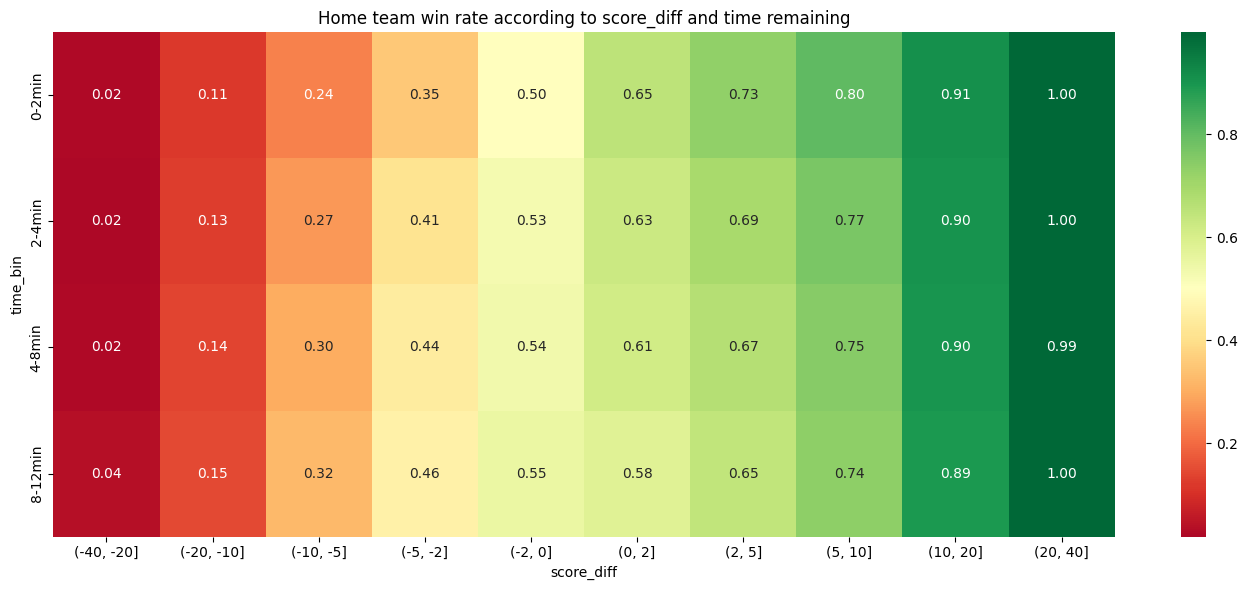

In [47]:
# Discretize time using 2min slices
big_training_df['time_bin'] = pd.cut(big_training_df['time_remaining'], 
                         bins=[0,120,240,480,720,1080,1440,1800,2160,2880],
                         labels=['0-2min','2-4min','4-8min','8-12min',
                                 'Q3 fin','Q3 début','Q2','Q1 fin','Q1 début'])

pivot = big_training_df.groupby(['time_bin', pd.cut(big_training_df['score_diff'], 
                    bins=[-40,-20,-10,-5,-2,0,2,5,10,20,40])])['home_win'].mean().unstack()

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5)
plt.title('Home team win rate according to score_diff and time remaining')
plt.tight_layout()

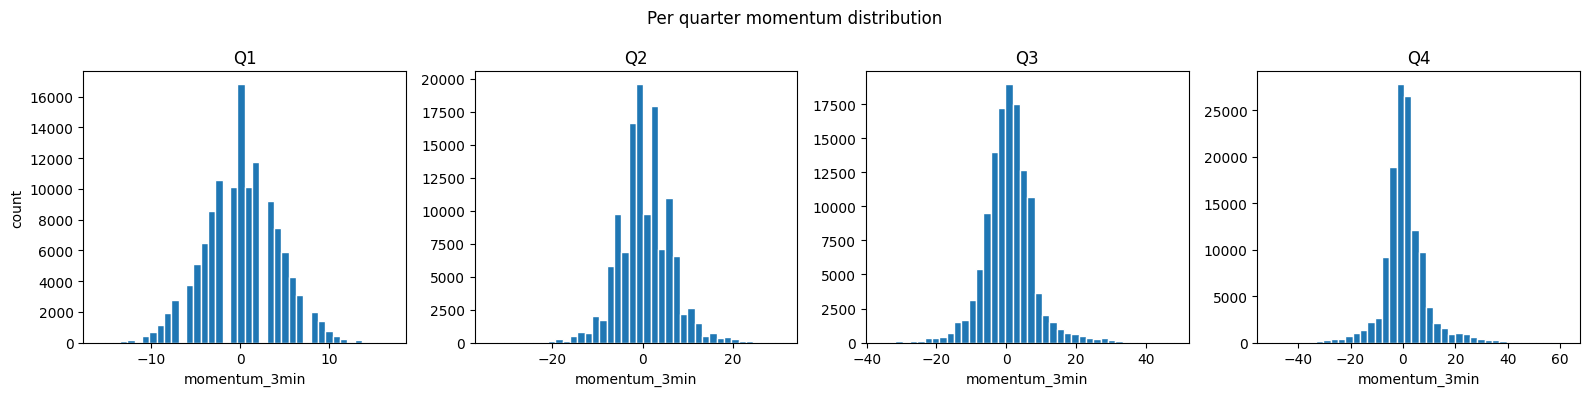

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, q in enumerate([1, 2, 3, 4]):
    data = big_training_df[big_training_df['quarter'] == q]['momentum_3min']
    axes[i].hist(data, bins=40, edgecolor='white')
    axes[i].set_title(f'Q{q}')
    axes[i].set_xlabel('momentum_3min')
axes[0].set_ylabel('count')
plt.suptitle('Per quarter momentum distribution')
plt.tight_layout()

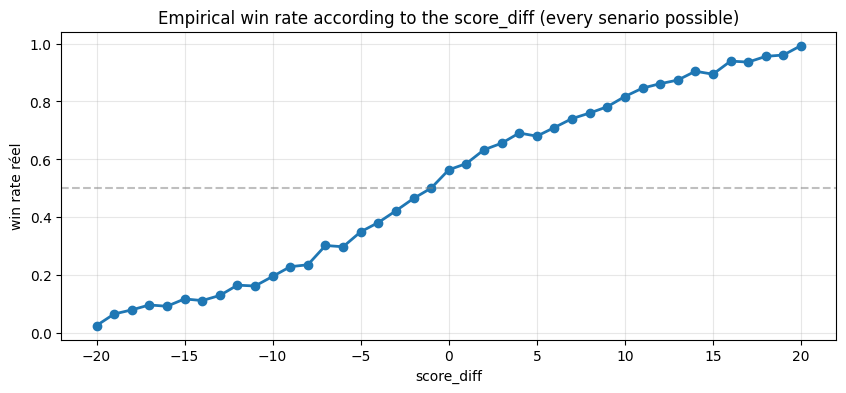

In [ ]:
# Is the win rate alone a good predictor ?
big_training_df['score_diff_clipped'] = big_training_df['score_diff'].clip(-20, 20)
calib = big_training_df.groupby('score_diff_clipped')['home_win'].mean()

plt.figure(figsize=(10, 4))
plt.plot(calib.index, calib.values, marker='o', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('score_diff')
plt.ylabel('win rate réel')
plt.title('Empirical win rate according to the score_diff (every senario possible)')
plt.grid(alpha=0.3)

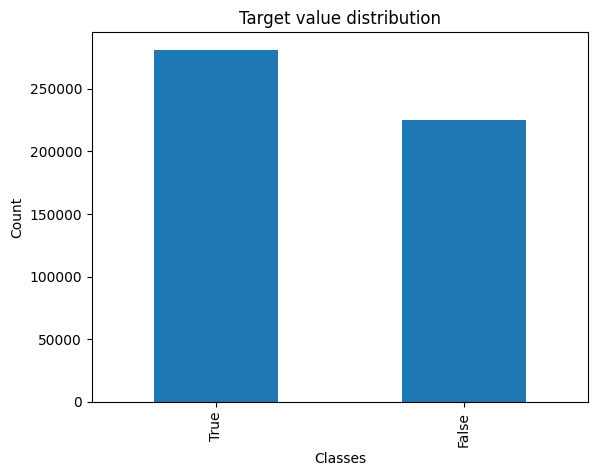

In [54]:
# Looking at the class imbalance
plt.figure()

big_training_df["home_win"].value_counts().plot(kind="bar")

plt.xlabel("Classes")
plt.ylabel("Count")
plt.title("Target value distribution")

plt.show()


Thanks to the plot above we can see that for the past season (all the data we have) both classes are quite well balanced which is something positive for the future.

In [17]:
X = big_training_df.drop(['home_win','GAME_ID'], axis=1)

In [23]:
y = big_training_df['home_win']

In [ ]:
X

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
tsne = TSNE(
    n_components=2,      # projection 2D
    perplexity=30,       # souvent entre 5 et 50
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

In [24]:
tsne_df = pd.DataFrame({
    "TSNE_1": X_tsne[:, 0],
    "TSNE_2": X_tsne[:, 1],
    "target": y.values
})

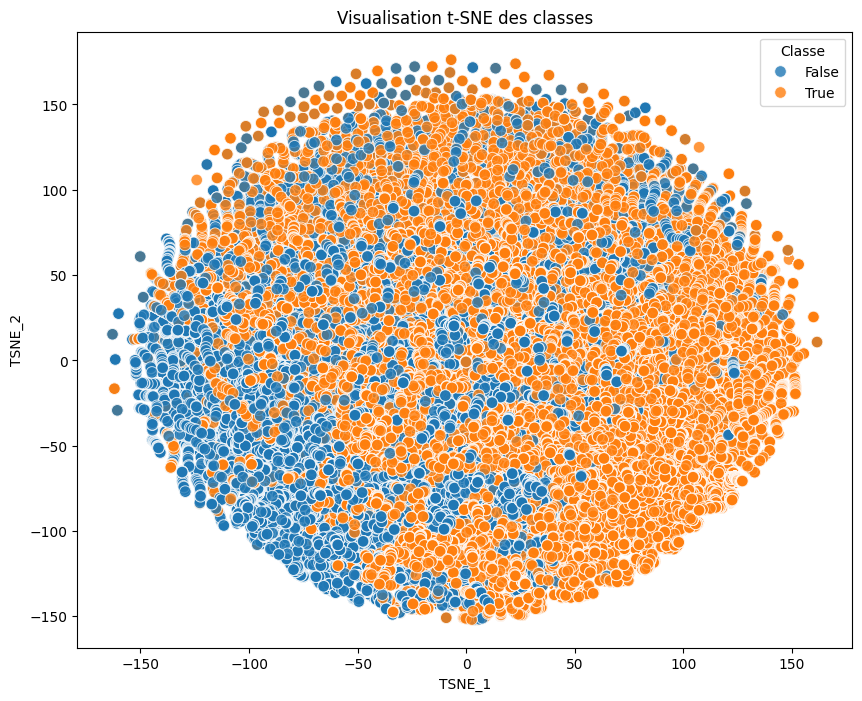

In [25]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=tsne_df,
    x="TSNE_1",
    y="TSNE_2",
    hue="target",
    palette="tab10",
    s=70,
    alpha=0.8
)

plt.title("Visualisation t-SNE des classes")
plt.legend(title="Classe")
plt.show()

Thanks to the above plot we can identify that our classification problem may not be that simple since our data does not seem linearly separable. Maybe we will need a complex model in order to find differences between the two classes